# Fine-Tune a Support Ticket Router — Qwen3-1.7B + LoRA

Teach a small open-weight model to read a human-written IT helpdesk ticket and route
it to one of **seven queues**. The model never writes a reply — it reads intent, emits
a single label, and the rest of your tooling takes over.

|  |  |
|---|---|
| **Base model** | `Qwen/Qwen3-1.7B-Base` |
| **Method** | LoRA adapter fine-tuning, driven from the LLaMA-Factory **LLaMA Board** web UI |
| **Data** | `support_tickets.csv` — 5,000 labelled tickets, 7 classes, ~714 per class |
| **Runtime** | free Colab **T4 GPU** — *Runtime → Change runtime type → T4 GPU* |
| **Wall clock** | ~10 min install + **~2–3 h** training (750 steps on a T4) + ~10 min evaluation |

LLaMA-Factory project homepage: https://github.com/hiyouga/LLaMA-Factory

### The route map

| Step | What happens | You do |
|---|---|---|
| 1 | Install LLaMA-Factory, verify the GPU | run |
| 2 | Load the CSV, stratified 80/20 split, write ShareGPT JSON, register the dataset | **upload the CSV** |
| 3 | Launch LLaMA Board and train the LoRA adapter | **drive the UI, then stop the cell** |
| 4 | Plot the training loss curve | **paste the adapter output dir** |
| 5 | Score the untouched base model (the baseline), then merge the adapter | run |
| 6 | Define `classify()`, smoke-test it, evaluate on the held-out split | run |
| 7 | Classification report → confusion matrix → baseline-vs-fine-tuned chart | run |

Three cells need human input and are marked **(INPUT REQUIRED)**. Everything else runs top to bottom.

### Results from the reference run (saved in this notebook)

| | Base model | Fine-tuned | Δ |
|---|---|---|---|
| Overall accuracy on 1,000 held-out tickets | **20.9 %** | **98.1 %** | **+77.2 pts** |

19 errors out of 1,000. Full per-class breakdown is in the evaluation section below and in `README.md`.

> **Note on the saved outputs.** The per-class rows in the two `classification_report`
> printouts below were generated *before* a fix to this notebook (`labels=` is now pinned
> in cells 5.2, 5.4 and 5.7b, so the class names line up with the rows). The saved
> report text and the comparison chart still show the pre-fix class names; the confusion
> matrix was always correct. Re-run those cells to regenerate them. The corrected numbers
> are tabulated in the markdown under each cell.

## Project architecture

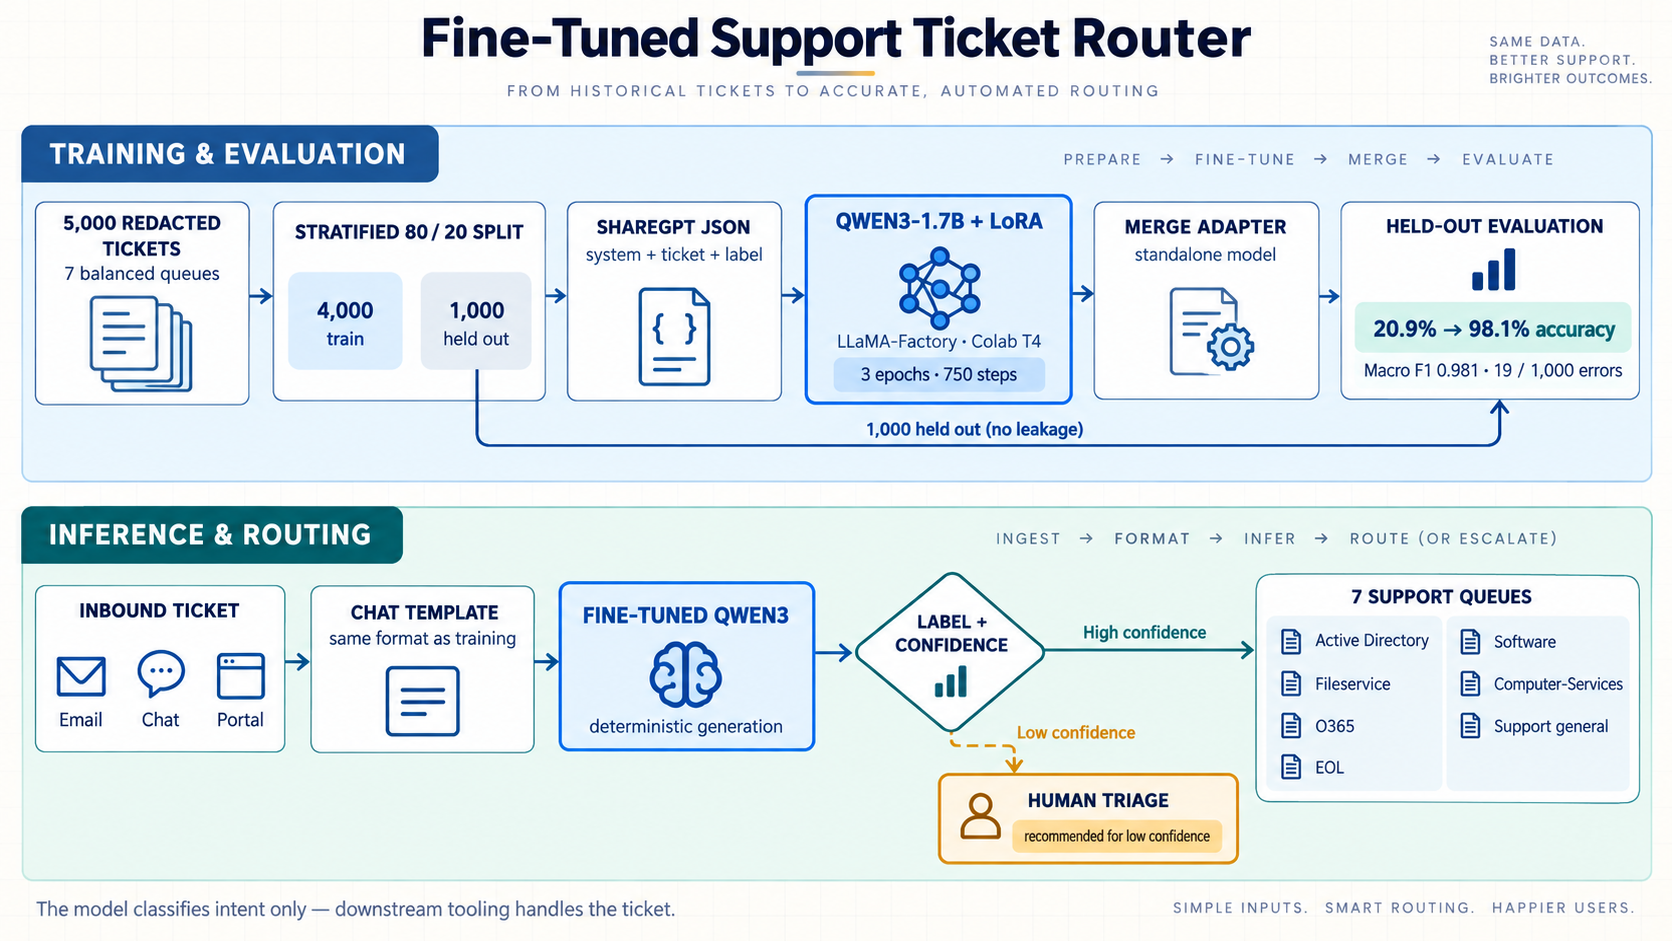

The supplied diagram summarizes training and the intended routing workflow. Email/chat/portal ingestion, queue dispatch, and confidence-based human triage are proposed extensions, not implemented integrations. The 4,000 rows form a training pool; the internal validation setting and reconstructed three-epoch schedule are unresolved. “No leakage” means the held-out rows are excluded from TRAIN.json; semantic overlap has not been audited. Confidence is an uncalibrated first-token score, and the two reported accuracies use different decision rules.

See the [project paper](docs/project-paper.md) and [reproduction guide](docs/reproducibility.md) for the reviewed methodology, corrected class mappings, and configuration limitations. The diagram is embedded in this notebook; its source image is stored at `docs/images/Architecture.png`.


---
## The Scenario

You're a senior engineer at a fast-growing IT services team. Your helpdesk handles a steady stream of human-written tickets every day — inbound across email, Slack, and your help portal. Today, every ticket touches a human before it reaches the right queue. A triage agent reads it, decides intent, and routes it manually. That's hours of human time daily, and it scales linearly with your user base.

You fix this by deploying a lightweight classifier at the front of the pipeline. Every ticket hits the model first:

```
Active Directory   → identity and access team, account and login workflows
Fileservice        → file share and network drive permissions
O365               → Outlook, Skype, Teams, OneDrive, mailbox issues
EOL                → server retirement and decommissioning tasks
Software           → application installs, updates, and app access
Computer-Services  → printers, scanners, drivers, and device support
Support general    → everything else that needs a human triage pass
```

The model never writes a response. It reads intent and fires a webhook. The rest of your tooling takes over.

**Why not a frontier model?**
At scale, a frontier model is overkill for a seven-class router. A fine-tuned ~1.7B model serves the same call from a single modest instance at a fraction of the per-ticket cost and latency. That's the actual business case for fine-tuning: not raw capability, but cost and latency at scale on a well-scoped task. (Treat any specific $/ms figure as workload-dependent — measure it on your own hardware before quoting it.)

**Why not keyword matching or regex?**
"I can't access the shared folder" — Fileservice or Active Directory? "Outlook keeps asking me to sign in" — O365 or Software? "The printer driver won't install and the scanner is offline" — both. Natural language is compositional and ambiguous. Rule-based routers fail on negation, multi-intent tickets, and phrasing variation. In practice, keyword routing misclassifies a meaningful slice of real support volume, which means your automation quietly generates more work than it saves.

A fine-tuned model learns intent from context. That's the difference between a brittle script and a reliable system component.

---

## 1. Install Dependencies

### Robot checkpoint — Environment ready

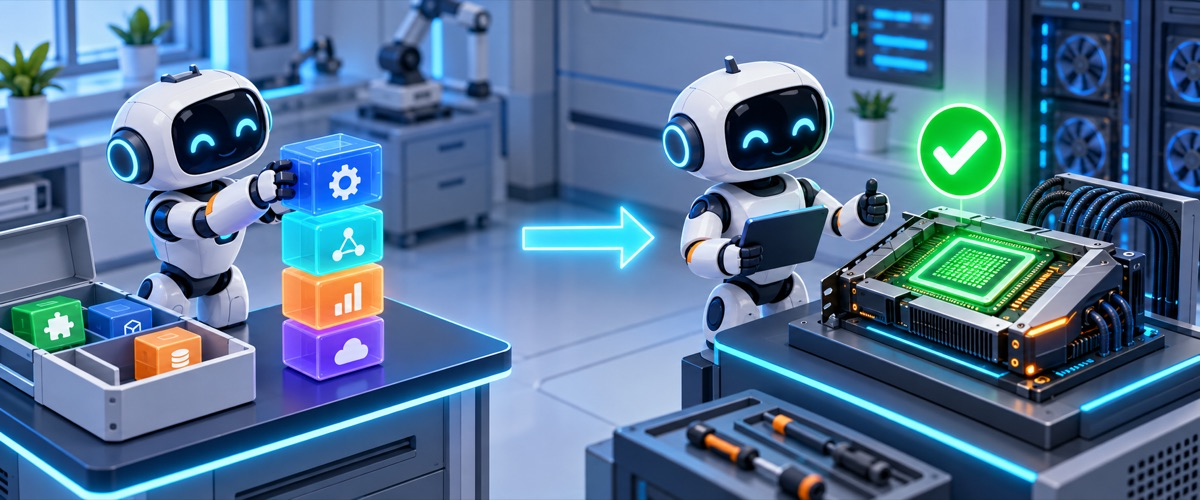

| Flow | Pass signal | Investigate if |
|---|---|---|
| Install the stack → verify CUDA → continue on an attached GPU | Installation ends successfully and the GPU check stays silent. | A package install stops, or the CUDA cell prints the no-GPU message. |

Clones LLaMA-Factory into `/content` and installs it in editable mode with the
`torch` and `bitsandbytes` extras. This pins a specific set of `transformers`,
`peft`, `trl`, `datasets` and `gradio` versions into the Colab runtime.

**What you'll see:** a long pip log ending in `Successfully installed ... llamafactory-0.9.x ...`.
Red `ERROR: pip's dependency resolver ...` lines about `google-genai`, `gcsfs`, `python-fasthtml`
and friends are **expected** — those are pre-installed Colab packages this notebook does not
use. As long as the final `Successfully installed` line appears, you're fine.

If Colab prompts you to restart the runtime, **do not restart** — just continue to the next cell.

In [1]:
%cd /content/
%rm -rf LLaMA-Factory
!git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git
%cd LLaMA-Factory
%ls
!pip install -e .[torch,bitsandbytes]

/content
Cloning into 'LLaMA-Factory'...
remote: Enumerating objects: 729, done.
remote: Counting objects: 100% (729/729), done.
remote: Compressing objects: 100% (570/570), done.
remote: Total 729 (delta 160), reused 434 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (729/729), 5.49 MiB | 3.91 MiB/s, done.
Resolving deltas: 100% (160/160), done.
/content/LLaMA-Factory
assets/       data/    examples/  MANIFEST.in     README_zh.md   src/
CITATION.cff  docker/  LICENSE    pyproject.toml  requirements/  tests/
CLAUDE.md@    docs/    Makefile   README.md       scripts/       tests_v1/
Obtaining file:///content/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

### Check GPU environment

Asserts that CUDA is visible. Silence means success; a printed message means no GPU is
attached and training will not work. Fix it with *Runtime → Change runtime type → T4 GPU*,
then re-run from the top.

In [2]:
import torch
try:
  assert torch.cuda.is_available() is True
except AssertionError:
  print("Please set up a GPU before using LLaMA Factory: https://medium.com/mlearning-ai/training-yolov4-on-google-colab-316f8fff99c6")

## Update Identity Dataset *(optional — not used by this project)*

This cell is inherited from the upstream LLaMA-Factory demo notebook. It rewrites the
`{{name}}` / `{{author}}` placeholders in LLaMA-Factory's bundled `data/identity.json`
so a model trained on that dataset answers "who are you?" consistently.

**We never train on `identity.json`** — the router is trained only on `support_tickets`.
Running it is harmless (its only output is the `%cd` path echo) and you can safely skip it.
It is kept so the notebook stays diffable against the upstream original.

In [3]:
import json

%cd /content/LLaMA-Factory/

NAME = "Llama-3"
AUTHOR = "LLaMA Factory"

with open("data/identity.json", "r", encoding="utf-8") as f:
  dataset = json.load(f)

for sample in dataset:
  sample["output"] = sample["output"].replace("{{"+ "name" + "}}", NAME).replace("{{"+ "author" + "}}", AUTHOR)

with open("data/identity.json", "w", encoding="utf-8") as f:
  json.dump(dataset, f, indent=2, ensure_ascii=False)

/content/LLaMA-Factory


---
## 2. Prepare Support Ticket Dataset **(INPUT REQUIRED)**

### Robot checkpoint — Balanced data, protected test set

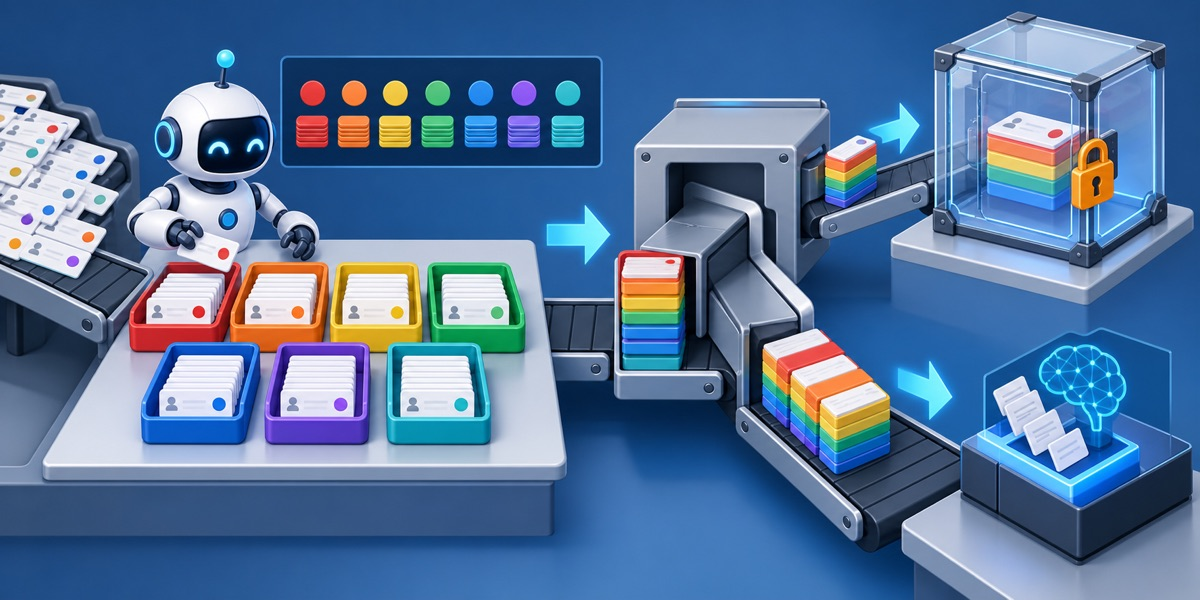

| Flow | Pass signal | Investigate if |
|---|---|---|
| Upload → clean seven labels → stratified 80/20 split → train JSON + locked holdout | About 4,000 training rows and 1,000 held-out rows are written with balanced classes. | Required columns are missing, labels are dropped unexpectedly, or class counts skew. |

Run this cell and upload `support_tickets.csv` from your local machine when the file
picker appears.

### What the code does, in order

1. **Upload** — `files.upload()` opens a Colab file picker and returns the uploaded filename.
2. **Load and filter** — reads the CSV, renames `category_truth` → `label`, drops any row whose
   label is not one of the seven known classes, then shuffles with `random_state=42`.
3. **Split** — `train_test_split(..., test_size=0.2, stratify=df["label"], random_state=42)`
   produces a **stratified** 80/20 split: 4,000 training rows and 1,000 held-out rows with the
   class balance preserved in both halves. Stratifying matters here because per-class recall is
   the metric we care about — a random split could under-represent a class in the held-out set
   and make its recall estimate noisy.
4. **Convert to ShareGPT JSON** — each ticket becomes a three-turn conversation:
   a fixed `system` prompt naming the seven categories, a `user` turn containing
   `Support Ticket: <text>`, and an `assistant` turn containing *only* the label.
   Training computes loss on the assistant turn, so the model learns to emit exactly one
   label string and nothing else. Written to `/content/LLaMA-Factory/data/TRAIN.json`.
5. **Register the dataset** — adds a `support_tickets` entry to
   `/content/LLaMA-Factory/data/dataset_info.json` describing the format and the role/content
   tag names. This is what makes `support_tickets` selectable in the LLaMA Board UI.
6. **Save the held-out split** — writes `/content/val_split.csv` for the evaluation cells later.

### The system prompt

The same `SYSTEM_PROMPT` string is used at training time (here) and at inference time
(cell 5.3). If you change it in one place you must change it in the other — a mismatched
system prompt at inference is one of the most common causes of a model that trained fine
but scores badly.

> **Held-out, not "validation".** The 1,000 rows saved here are never shown to the trainer.
> LLaMA Board carves its *own* validation slice out of `TRAIN.json` (the **Val size** field),
> so the accuracy reported at the end of this notebook is a genuine held-out estimate.

In [4]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files

# ── constants ──────────────────────────────────────────────────────────────────
LLAMA_DATA_DIR = "/content/LLaMA-Factory/data"
TRAIN_JSON_PATH = f"{LLAMA_DATA_DIR}/TRAIN.json"
DATASET_INFO    = f"{LLAMA_DATA_DIR}/dataset_info.json"

LABEL2ID = {
    "Support general":   0,
    "Fileservice":       1,
    "O365":              2,
    "EOL":               3,
    "Software":          4,
    "Active Directory":  5,
    "Computer-Services": 6,
}

SYSTEM_PROMPT = (
    "You are an IT helpdesk ticket routing assistant. "
    "Given a support ticket, respond with exactly one of the following categories: "
    "Support general, Fileservice, O365, EOL, Software, Active Directory, Computer-Services."
)

# ── 1. Upload CSV ──────────────────────────────────────────────────────────────
print("Upload support_ticket.csv:")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]

# ── 2. Load + filter ───────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH).rename(columns={"category_truth": "label"})
df = df[df["label"].isin(LABEL2ID)].sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Loaded {len(df):,} rows")
print(df["label"].value_counts())

# ── 3. Stratified train/val split on the full dataset ─────────────────────────
df_train, df_val = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42,
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
print(f"\nTrain: {len(df_train):,} rows | Val (held-out): {len(df_val):,} rows")
print("\nTrain label distribution:")
print(df_train["label"].value_counts())

# ── 4. Convert train split → ShareGPT JSON ────────────────────────────────────
sharegpt_records = [
    {
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": f"Support Ticket: {row['text']}"},
            {"role": "assistant", "content": row["label"]},
        ]
    }
    for _, row in df_train.iterrows()
]

with open(TRAIN_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(sharegpt_records, f, indent=2, ensure_ascii=False)
print(f"\nWritten {len(sharegpt_records):,} records → {TRAIN_JSON_PATH}")

# ── 5. Register dataset in dataset_info.json ──────────────────────────────────
with open(DATASET_INFO, "r", encoding="utf-8") as f:
    info = json.load(f)

info["support_tickets"] = {
    "file_name": "TRAIN.json",
    "formatting": "sharegpt",
    "columns":   {"messages": "messages"},
    "tags": {
        "role_tag":      "role",
        "content_tag":   "content",
        "user_tag":      "user",
        "assistant_tag": "assistant",
        "system_tag":    "system",
    },
}

with open(DATASET_INFO, "w", encoding="utf-8") as f:
    json.dump(info, f, indent=2, ensure_ascii=False)
print(f"Registered 'support_tickets' in {DATASET_INFO}")

# ── 6. Save val split for evaluation ──────────────────────────────────────────
VAL_CSV = "/content/val_split.csv"
df_val.to_csv(VAL_CSV, index=False)
print(f"Val split saved → {VAL_CSV}  ({len(df_val):,} rows)")

Upload support_ticket.csv:


Saving support_tickets.csv to support_tickets.csv
Loaded 5,000 rows
label
Support general      715
Active Directory     715
Software             714
O365                 714
Computer-Services    714
EOL                  714
Fileservice          714
Name: count, dtype: int64

Train: 4,000 rows | Val (held-out): 1,000 rows

Train label distribution:
label
EOL                  572
Support general      572
Active Directory     572
Software             571
O365                 571
Fileservice          571
Computer-Services    571
Name: count, dtype: int64

Written 4,000 records → /content/LLaMA-Factory/data/TRAIN.json
Registered 'support_tickets' in /content/LLaMA-Factory/data/dataset_info.json
Val split saved → /content/val_split.csv  (1,000 rows)


### Reading the output

```
Loaded 5,000 rows
label
Support general      715
Active Directory     715
Software             714
...
Train: 4,000 rows | Val (held-out): 1,000 rows
Written 4,000 records → /content/LLaMA-Factory/data/TRAIN.json
Registered 'support_tickets' in /content/LLaMA-Factory/data/dataset_info.json
Val split saved → /content/val_split.csv  (1,000 rows)
```

Three things to check before moving on:

- **5,000 rows loaded.** A smaller number means rows were dropped by the label filter —
  usually a typo or a stray class in the CSV.
- **The class counts are near-identical** (714–715 each, and 571–572 each after the split).
  This dataset is deliberately balanced, so a skewed count means something went wrong upstream.
  Balanced classes also make the headline accuracy directly comparable to the 1/7 ≈ 14.3 %
  random-guess floor.
- **`Registered 'support_tickets'`** printed. If this line is missing, the dataset will not
  appear in the LLaMA Board dropdown in the next step.

---
## 3. Fine-tune via LLaMA Board **(INPUT REQUIRED)**

### Robot checkpoint — Train only the lightweight adapter

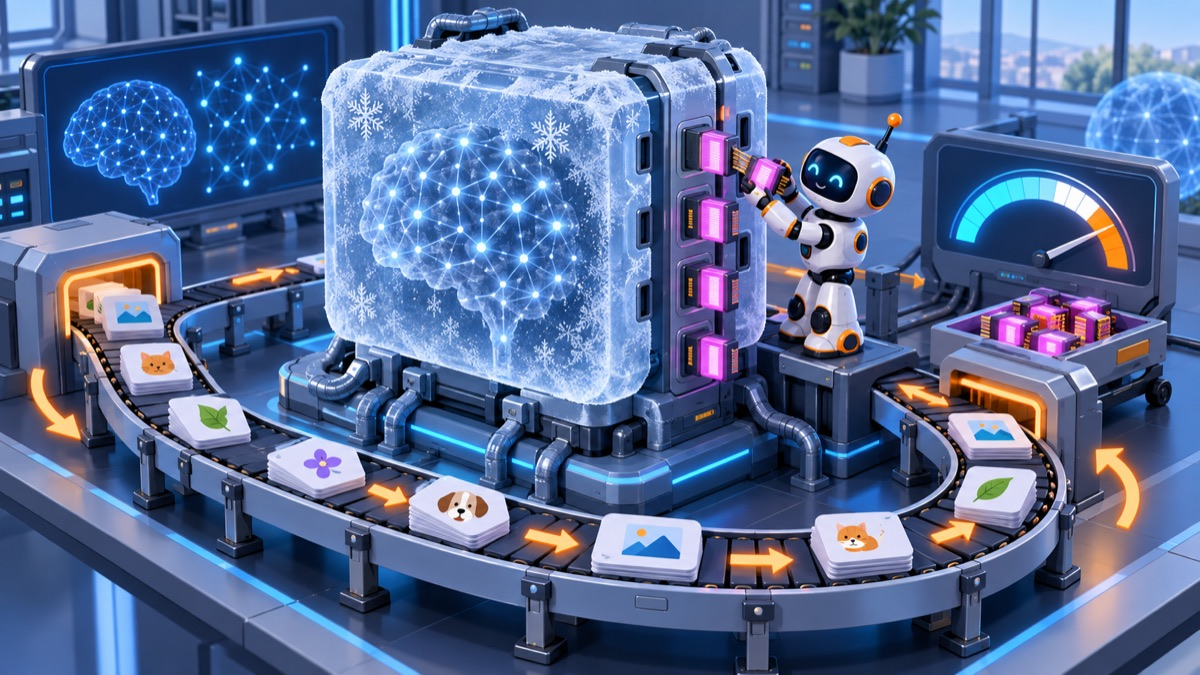

| Flow | Pass signal | Investigate if |
|---|---|---|
| Frozen base model + small LoRA modules → repeated ticket passes → saved adapter | The UI reports training complete, loss trends down, and an adapter output directory exists. | GPU memory errors appear, loss stays flat or diverges, or no checkpoint is saved. |

This cell starts a Gradio web server *inside* the Colab VM and tunnels it to a public URL.
Training is driven from that browser UI, not from the notebook.

1. Run the cell. Wait for the two URLs in the output, then open the **public** one
   (`https://xxxxxxxx.gradio.live`).
2. In the **Train** tab set:
   - **Model name** → `Qwen/Qwen3-1.7B-Base`
   - **Finetuning method** → `lora`
   - **Dataset** → `support_tickets`
   - **Val size** → `0.1` (lets LLaMA Board show you a validation loss during the run)
   - everything else → defaults are a good first run (see the reference table below)
3. Click **Start**. Watch the loss plot in the UI. Wait for the `training completed`
   notification at the bottom of the log panel. Intermittent "syntax error" toasts are a
   known LLaMA Board quirk and do **not** affect training.
4. **Copy the `Output Dir` path** shown in the UI — something like
   `saves/Qwen3-1.7B-Base/lora/train_2026-09-11-17-48-28`. You need the full path
   (`/content/LLaMA-Factory/` + that) for the next cell.
5. **Stop this cell manually** (the ■ button). It is a server daemon — Colab will never
   stop it on its own, and the cells below cannot run while it holds the kernel.

### What the reference run actually used

All LLaMA Board defaults were kept. Reconstructed from the run's own logs:

| Setting | Value | How we know |
|---|---|---|
| Base model | `Qwen/Qwen3-1.7B-Base` | Output dir `saves/Qwen3-1.7B-Base/lora/...` |
| Stage / method | Supervised fine-tuning, **LoRA** | same path |
| Dataset | `support_tickets` (4,000 rows) | registered in step 2 |
| Epochs | **3** | 750 total steps ÷ 250 steps per epoch |
| Effective batch size | **16** (batch 2 × grad accum 8) | 4,000 rows ÷ 250 steps |
| Learning rate | **5e-5** | LR at epoch 2.00 was 1.2591e-05 = 5e-5 × cosine(⅔) |
| LR scheduler | **cosine** | LR decay matches a cosine curve, not linear |
| Logging interval | every 5 steps | epoch advances 0.02 per log line |
| Device count | 1 | shown in the UI |
| DeepSpeed | none | shown in the UI |
| Throughput | ~140 tokens/s | `'throughput': 140.49` in the log |

**Budget the time honestly.** The upstream notebook says 30–60 min, but this run logged
~5 optimiser steps per minute (≈12 s/step): it started at 17:48, was only at epoch 2.00 by
19:46, and needed roughly **2–3 hours** end to end for all 750 steps. Keep the Colab tab
awake — a disconnect loses the adapter. If you need it faster, cut epochs to 1–2 (the loss
curve shows it is essentially converged well before epoch 1) or raise the batch size.

### Two UI messages you can ignore

- **`Could not parse server response: SyntaxError: Unexpected token '<'`** — a red toast in
  the top-right. This is the known LLaMA Board / Gradio polling quirk. Training is unaffected;
  the log panel keeps updating behind it.
- **`Finished.`** above the log panel is the real completion signal, alongside
  `trainer.py >> Saving model checkpoint to saves/Qwen3-1.7B-Base/lora/train_...`.

A transcript of the reference run's log is in `docs/llama-board-training-log.md`.

> **The public URL is a temporary tunnel.** It dies the moment you stop this cell, and
> expires after a week regardless. A 404 on an old `gradio.live` link just means the tunnel
> is gone — re-run this cell to get a fresh one. The trained adapter lives on the Colab disk
> and is unaffected.

### Hyperparameter Reference

The table below covers every parameter visible in the LLaMA Board Train tab. Use it to decide what to change if your first run underperforms.

Ordered by priority of tuning. Realistically, you only need to tune learning rate, epochs, batch size, and *maybe* LoRA rank. But you're perfectly fine using the defaults for a first run!

| Parameter | What it controls | Too high | Too low |
|-----------|-----------------|----------|---------|
| **Learning rate** | The step size the optimiser takes each update. Controls how aggressively the model updates toward each training example. | Loss spikes or diverges; model "unlearns" general knowledge (catastrophic forgetting) | Loss decreases very slowly; you need many more epochs to converge |
| **Epochs** | How many full passes over the training data the optimiser makes. | Model overfits — memorises training tickets and fails to generalise to new ones | Model underfits — loss is still falling when training stops; accuracy left on the table |
| **Batch size** | Number of samples processed together before each weight update. Larger batches give smoother gradient estimates but use more VRAM. | Runs out of VRAM; or gradients become too smooth and training stalls | Noisy gradient estimates; loss curve is jagged; training is slower wall-clock |
| **LoRA rank (r)** | Dimension of the low-rank matrices injected at each target layer. Higher rank = more trainable parameters = more expressive adapter. | More VRAM, slower training, risk of overfitting on small datasets | Adapter has too little capacity to capture the routing task; accuracy plateaus |
| **Gradient accumulation** | Simulates a larger batch by accumulating gradients over this many steps before updating. Effective batch = batch size × accumulation. | Effective batch becomes so large that small-dataset signal is washed out | Same as low batch size — noisy updates |
| **Cutoff length** | Maximum token length of each training example. Examples longer than this are truncated. | No downside except more VRAM and slower steps | Long tickets get silently truncated; model never sees the full context for complex tickets |
| **Max gradient norm** | Clips the gradient vector to this L2 norm before each update. Prevents a single bad batch from causing a catastrophically large weight update. | Gradients are never clipped; a noisy batch can cause a loss spike | Gradients are clipped too aggressively; effective learning rate is much lower than set; training slows |
| **LR scheduler** | Controls how the learning rate changes over training. `cosine` warms up then smoothly decays to near zero. `linear` decays linearly. `constant` never changes. | N/A — this is a choice, not a magnitude | N/A |
| **Compute type** | Numerical precision during training. `bf16` is standard on modern GPUs (A100, H100); `fp16` for older hardware (T4); `fp32` uses full precision but 2× the VRAM. | N/A — match to your GPU | Using `fp32` on a T4 will likely OOM |



In [5]:
%cd /content/LLaMA-Factory/
!GRADIO_SHARE=1 llamafactory-cli webui

/content/LLaMA-Factory
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.13/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Visit http://ip:port for Web UI, e.g., http://127.0.0.1:7860
* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://332de1

---
## 4. Review Training — Loss Curve **(INPUT REQUIRED)**

### Robot checkpoint — Read the training health signal

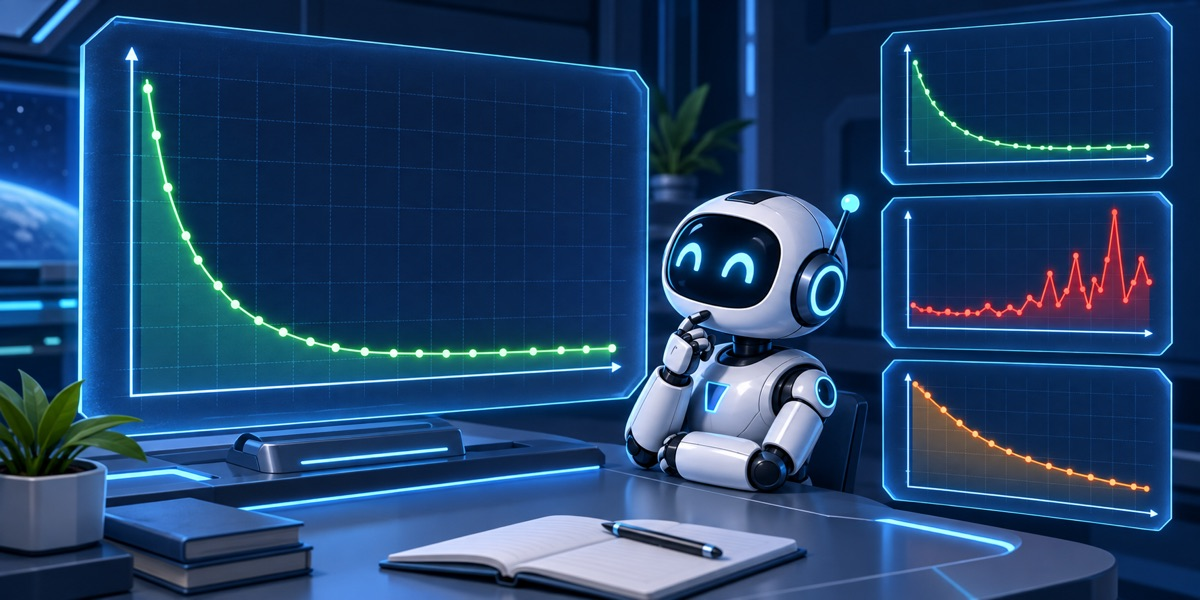

| Flow | Pass signal | Investigate if |
|---|---|---|
| Load trainer log → plot loss by step → compare the curve shape with failure patterns | Loss falls sharply, remains finite, and settles into a low plateau. | A flat start suggests no learning; spikes suggest instability; a falling endpoint suggests undertraining. |

**Set `ADAPTER_DIR` below to the Output Dir you copied from LLaMA Board**, prefixed with
`/content/LLaMA-Factory/`. The other two constants (`MERGED_DIR`, `BASE_MODEL_NAME`) are
also defined here and used by every cell that follows — this is effectively the
configuration cell for the second half of the notebook.

The code reads `trainer_log.jsonl` from the adapter directory — one JSON object per logged
step — keeps the records that carry a `loss` field, and plots loss against step. It saves
the figure to `/content/training_curve.png` and prints the first loss, the last loss, and
the drop between them.

### What a healthy curve looks like

A steep fall in the first tens of steps, then a flattening tail. Watch for:

- **Flat from the start** → the learning rate is far too low, or the chat template /
  data format is wrong and the model is being asked to predict noise.
- **Spiking or diverging** → learning rate too high; halve it and retrain.
- **Still falling at the last step** → undertrained; add epochs.

Note this is *training* loss. It cannot tell you about overfitting on its own — that is what
the held-out evaluation further down is for.

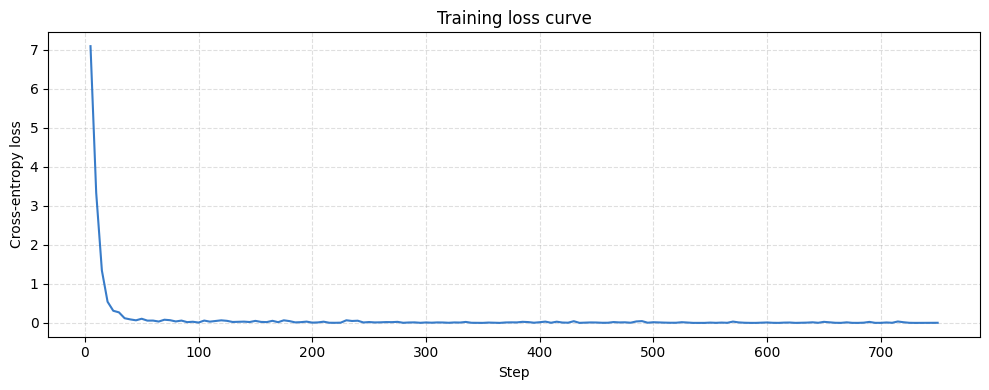

Starting loss : 7.0881
Final loss    : 0.0028
Total drop    : 7.0853

Loss is low — model has likely converged well.


In [6]:
import json, matplotlib.pyplot as plt
from pathlib import Path

ADAPTER_DIR = "/content/LLaMA-Factory/saves/Qwen3-1.7B-Base/lora/train_2026-09-11-17-48-28"  # <-- CHANGE THIS
MERGED_DIR      = "/content/qwen3_merged"
BASE_MODEL_NAME = "Qwen/Qwen3-1.7B-Base"

log_file = Path(ADAPTER_DIR) / "trainer_log.jsonl"
if not log_file.exists():
    raise FileNotFoundError(f"trainer_log.jsonl not found in {ADAPTER_DIR!r}")

records = [json.loads(l) for l in log_file.read_text().splitlines() if l.strip()]
steps   = [r["current_steps"] for r in records if r.get("loss") is not None]
losses  = [r["loss"]          for r in records if r.get("loss") is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, losses, linewidth=1.5, color="#1565C0", alpha=0.85)
ax.set_xlabel("Step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training loss curve")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("/content/training_curve.png", dpi=120)
plt.show()

total_drop = losses[0] - losses[-1]
print(f"Starting loss : {losses[0]:.4f}")
print(f"Final loss    : {losses[-1]:.4f}")
print(f"Total drop    : {total_drop:.4f}")
print()
if losses[-1] < 0.5:
    print("Loss is low — model has likely converged well.")
elif losses[-1] < 1.2:
    print("Loss is moderate — model has learned but may benefit from more epochs.")
else:
    print("Loss is still high — consider more epochs, a lower learning rate, or checking the data format.")


### Reading the loss curve

The reference run printed:

```
Starting loss : 7.0881
Final loss    : 0.0028
Total drop    : 7.0853
```

- **7.09 at step 0** is the untrained model's cross-entropy on the label tokens — it has no
  idea that `Support Ticket: ...` should be answered with one of seven fixed strings.
- **The collapse below 0.5 within ~40 steps** is typical for classification-style fine-tuning.
  The target is a short, fixed string from a tiny vocabulary, so the model locks onto the
  output format almost immediately; the remaining ~700 steps are spent learning which of the
  seven strings goes with which ticket.
- **0.0028 at step 750** is very low. On a free-form generation task that would read as
  memorisation. Here it is expected — the answer is one of seven strings — but it does mean
  the training loss has stopped being informative. **Only the held-out accuracy below tells
  you whether the model generalised.** In the reference run it did: 98.1 % on 1,000 tickets
  the trainer never saw.

---
## 5. Measure the Baseline, Then Merge the Adapter

### Robot checkpoint — Measure the control, then assemble the deployable model

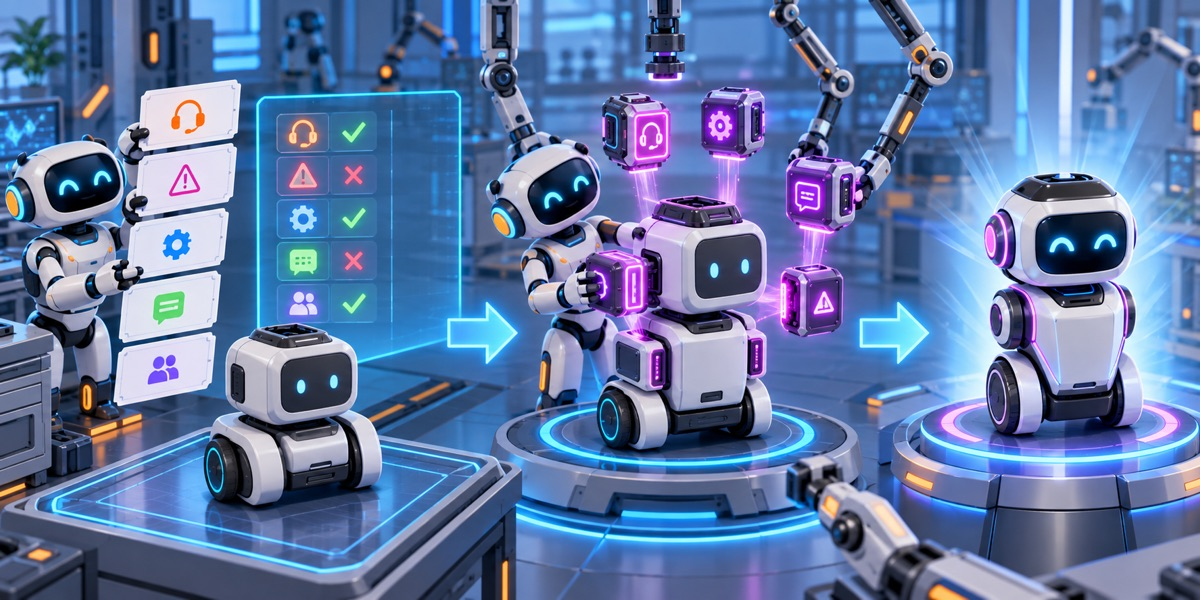

| Flow | Pass signal | Investigate if |
|---|---|---|
| Score untouched base → attach LoRA → merge weights → save one standalone model | Baseline metrics are captured before adaptation and the merged folder reloads as a plain model. | Adapter files are missing, memory is exhausted, or the baseline was measured after adaptation. |

### What is a LoRA adapter and why do we need to merge it?

During fine-tuning the original model weights were **frozen**. Instead of updating the full
weight matrices (billions of parameters), LoRA injects small trainable rank-decomposition
matrices alongside the frozen ones. Only those lightweight matrices were updated.

So after training you have two separate things on disk:

- the original **base model** weights (unchanged), and
- the **LoRA adapter** — a few megabytes of delta weights that encode everything learned.

That separation is efficient for training but adds a per-forward-pass cost at inference.
**Merging** folds the adapter deltas back into the base weights (`W + BA → W'`), producing a
single standalone model that behaves identically to the adapted one, has no adapter overhead,
and can be loaded anywhere a normal Hugging Face model can.

### Why measure the baseline *here*?

To know what fine-tuning contributed we need a **control**: the same weights, the same
tickets, zero task-specific training. We measure it at this exact point because the base
model is already in GPU memory and the adapter has not been attached yet. Doing it here is
free; doing it later would mean loading a second copy of the model.

### How the baseline is scored, and why it's a *fair* baseline

A naive baseline would ask the untrained model to generate the label string and then
string-match it. That measures formatting luck, not routing ability — the base model has no
reason to prefer `"Active Directory"` over `"AD"`, `"active directory"`, or a whole sentence.

Instead the baseline gets a **constrained multiple-choice prompt**: the seven classes are
presented as options `A)`–`G)`, the model does one forward pass, and we compare the logits of
exactly those seven single letter tokens at the first generated position. Single letters are
single tokens in this tokenizer, so the comparison is clean and the prediction is **always**
one of the seven classes. No parsing, no format failures — the base model's best shot.

### What this cell does, in order

1. Define the label set, the `A`–`G` choice map, and the baseline system prompt.
2. Validate that `ADAPTER_DIR` exists and contains `adapter_config.json`.
3. Pick the device (`cuda` → `mps` → `cpu`) and dtype (fp16 on GPU, fp32 on CPU).
4. Load the base model and tokenizer. The tokenizer is loaded from the adapter directory if
   it saved one, otherwise from the base model — this keeps any special tokens consistent.
5. Run **baseline inference** over all 1,000 held-out tickets → `y_pred_base`, `y_true`.
6. Print the baseline classification report.
7. Attach the LoRA config to the loaded base model, load the adapter weights
   (`adapter_model.safetensors`, with `.bin` fallbacks) and apply them.
8. `merge_and_unload()` — fold the deltas in and return a clean standalone model.
9. Save the merged model + tokenizer to `MERGED_DIR` and delete the stale
   `adapter_config.json` so the folder loads as a plain model.
10. Free the intermediates (`peft_model`, `base_model`, adapter weights) and empty the CUDA
    cache, leaving only `_model` live for the cells below.

Baseline inference over 1,000 tickets takes a few minutes on a T4. `Writing model shards`
during the merge takes longer for larger models.

In [7]:
import os, gc, json, torch, pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftConfig, get_peft_model
from peft.utils import set_peft_model_state_dict
import safetensors.torch as st

# ── USER INPUT ─────────────────────────────────────────────────────────────────

LABEL_TOKENS = [
    "Support general", "Fileservice", "O365", "EOL",
    "Software", "Active Directory", "Computer-Services",
]
CHOICES      = "ABCDEFG"
CHOICE2LABEL = {ch: lbl for ch, lbl in zip(CHOICES, LABEL_TOKENS)}

BASE_SYSTEM_PROMPT = (
    "You are an IT helpdesk ticket routing assistant. "
    "Classify the ticket by responding with ONLY a single letter — nothing else:\n"
    + "\n".join(f"{ch}) {lbl}" for ch, lbl in CHOICE2LABEL.items())
)

# ── Validate adapter ──────────────────────────────────────────────────────────
adapter_path = Path(ADAPTER_DIR)
if not adapter_path.is_dir():
    raise FileNotFoundError(f"Adapter folder not found: {ADAPTER_DIR!r}")
if not (adapter_path / "adapter_config.json").exists():
    raise FileNotFoundError(f"No adapter_config.json in {ADAPTER_DIR!r}")
print(f"Adapter found: {ADAPTER_DIR}")

# ── Device ────────────────────────────────────────────────────────────────────
HAS_CUDA = torch.cuda.is_available()
HAS_MPS  = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
DEVICE   = "cuda" if HAS_CUDA else ("mps" if HAS_MPS else "cpu")
dtype    = torch.float16 if DEVICE in ("cuda", "mps") else torch.float32
print(f"Device: {DEVICE}")

# ── Load base model + tokenizer ───────────────────────────────────────────────
print("\nLoading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, torch_dtype=dtype, device_map=DEVICE,
)
tok_src    = str(adapter_path) if (adapter_path / "tokenizer.json").exists() else BASE_MODEL_NAME
_tokenizer = AutoTokenizer.from_pretrained(tok_src)
base_model.eval()

# ── Baseline inference on val split ───────────────────────────────────────────
_choice_ids = []
for ch in CHOICES:
    ids_plain  = _tokenizer.encode(ch,       add_special_tokens=False)
    ids_spaced = _tokenizer.encode(f" {ch}", add_special_tokens=False)
    _choice_ids.append(ids_spaced[0] if len(ids_spaced) == 1 else ids_plain[0])


def classify_base(ticket_text: str) -> str:
    messages = [
        {"role": "system", "content": BASE_SYSTEM_PROMPT},
        {"role": "user",   "content": f"Support Ticket: {ticket_text}"},
    ]
    prompt = _tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = _tokenizer(prompt, return_tensors="pt").to(base_model.device)
    with torch.no_grad():
        out = base_model(input_ids=inputs["input_ids"])
    first_logits = out.logits[0, -1, :]
    choice_probs = torch.softmax(first_logits[_choice_ids], dim=-1).cpu().tolist()
    return CHOICE2LABEL[CHOICES[choice_probs.index(max(choice_probs))]]


df_val      = pd.read_csv("/content/val_split.csv")
y_true      = df_val["label"].tolist()
y_pred_base = []

for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Baseline inference"):
    y_pred_base.append(classify_base(row["text"]))

from sklearn.metrics import classification_report
print("\n=== Baseline (no fine-tuning) ===")
# labels= pins the row order to LABEL_TOKENS. Without it sklearn sorts the classes
# alphabetically while target_names keeps our order, so every per-class row would be
# printed under the wrong class name.
print(classification_report(y_true, y_pred_base, labels=LABEL_TOKENS,
                            target_names=LABEL_TOKENS, digits=3, zero_division=0))

# ── Attach LoRA + load weights ────────────────────────────────────────────────
print("Attaching LoRA adapter...")
peft_cfg   = PeftConfig.from_pretrained(str(adapter_path))
peft_model = get_peft_model(base_model, peft_cfg)

candidates = [
    adapter_path / "adapter_model.safetensors",
    adapter_path / "adapters.safetensors",
    adapter_path / "adapter_model.bin",
]
weights_file = next((p for p in candidates if p.exists()), None)
if weights_file is None:
    raise FileNotFoundError(f"No adapter weights in {ADAPTER_DIR}")

if weights_file.suffix == ".safetensors":
    adapter_weights = st.load_file(str(weights_file), device=DEVICE)
else:
    adapter_weights = torch.load(str(weights_file), map_location=DEVICE)

set_peft_model_state_dict(peft_model, adapter_weights)

# ── Merge + save to disk ──────────────────────────────────────────────────────
print("Merging (this may take a while) ...")
_model = peft_model.merge_and_unload()

os.makedirs(MERGED_DIR, exist_ok=True)
_model.save_pretrained(MERGED_DIR)
_tokenizer.save_pretrained(MERGED_DIR)
stale = Path(MERGED_DIR) / "adapter_config.json"
if stale.exists():
    stale.unlink()
print(f"Saved → {MERGED_DIR}")

# ── Drop intermediates, keep _model in place ──────────────────────────────────
del peft_model, base_model, adapter_weights
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

_model.eval()
print("Model ready for inference.")


Adapter found: /content/LLaMA-Factory/saves/Qwen3-1.7B-Base/lora/train_2026-09-11-17-48-28
Device: cuda

Loading base model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Baseline inference:   0%|          | 0/1000 [00:00<?, ?it/s]


=== Baseline (no fine-tuning) ===
                   precision    recall  f1-score   support

  Support general      1.000     0.007     0.014       143
      Fileservice      0.000     0.000     0.000       143
             O365      0.929     0.275     0.424       142
              EOL      1.000     0.098     0.178       143
         Software      0.333     0.007     0.014       143
 Active Directory      0.867     0.091     0.165       143
Computer-Services      0.152     0.986     0.264       143

         accuracy                          0.209      1000
        macro avg      0.612     0.209     0.151      1000
     weighted avg      0.611     0.209     0.151      1000

Attaching LoRA adapter...
Merging (this may take a while) ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved → /content/qwen3_merged
Model ready for inference.


### Reading the baseline report

> ⚠️ **The report printed above is mislabeled.** It was produced before `labels=LABEL_TOKENS`
> was added to the `classification_report` call. Without `labels=`, scikit-learn orders the
> rows **alphabetically** while `target_names` supplies *our* order, so every per-class row
> carries the wrong class name. The accuracy line (20.9 %) is unaffected. The code above is
> now fixed — re-run the cell to regenerate it. The corrected mapping is below.

**Baseline — zero-shot `Qwen3-1.7B-Base`, 1,000 held-out tickets, accuracy 20.9 %**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Active Directory | 1.000 | 0.007 | 0.014 | 143 |
| Computer-Services | 0.000 | 0.000 | 0.000 | 143 |
| EOL | 0.929 | 0.275 | 0.424 | 142 |
| Fileservice | 1.000 | 0.098 | 0.178 | 143 |
| O365 | 0.333 | 0.007 | 0.014 | 143 |
| Software | 0.867 | 0.091 | 0.165 | 143 |
| Support general | 0.152 | **0.986** | 0.264 | 143 |

### What this actually tells you

The shape of this table is more interesting than the 20.9 % headline:

- **The base model answers `A` for almost everything.** `Support general` is option `A)`,
  it recalls 98.6 % of the true `Support general` tickets, and its precision is 0.152 —
  meaning roughly 930 of the 1,000 tickets were routed there. This is **position bias**, a
  well-known failure mode of multiple-choice prompting on base (non-instruction-tuned) models.
- **20.9 % is barely above the 14.3 % random-guess floor** for seven balanced classes. Almost
  all of that margin comes from `Support general` being the default answer *and* a real class.
- **Where it does pick a non-`A` option, it is often right.** `EOL` recall 27.5 % at precision
  0.929, `Fileservice` precision 1.000 — the pre-trained model genuinely knows what
  "decommission this server" means. It just has no idea that this particular routing
  taxonomy exists, or that it is expected to commit to a choice.

That is precisely the gap fine-tuning closes: not language understanding, but **task
grounding** — mapping your label set onto your ticket distribution.

> **A caveat worth stating out loud.** The baseline is scored by single-letter logit
> comparison; the fine-tuned model below is scored by generating the label string and prefix
> matching it. The two paths are not identical, so part of the +77-point gap reflects the
> fine-tuned model's fluency with the output format rather than routing skill alone. The
> letter-choice design gives the base model the best shot it can get *without* changing
> the fine-tuned model's scoring, but a stricter apples-to-apples comparison would score
> **both** models by teacher-forced log-likelihood over the seven label strings. See the
> *Limitations* section of `README.md`.

---
## 6. Define `classify()` and Smoke Test the Merged Model

### Robot checkpoint — Quick wiring test before the long run

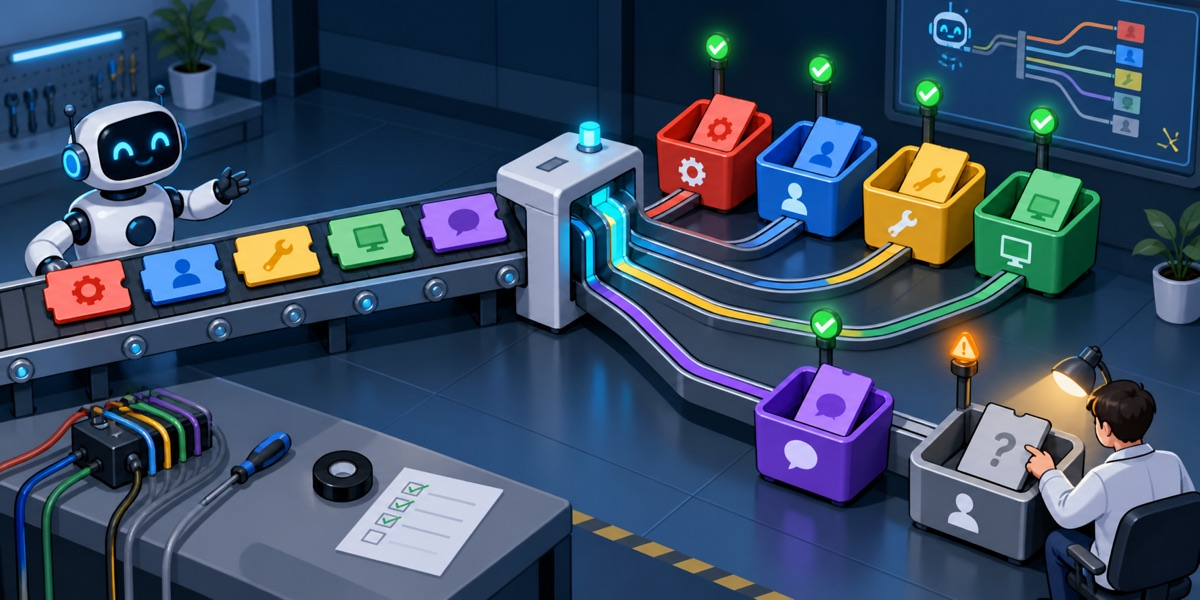

| Flow | Pass signal | Investigate if |
|---|---|---|
| Five clear tickets → classify → match a valid queue → inspect confidence and human-review fallback | Most or all obvious cases reach the expected queue; uncertainty is low-confidence rather than confidently wrong. | Several obvious cases fail, especially with high confidence—check the checkpoint and prompt template. |

### How inference works

`classify()` is the function you would actually ship. For one ticket it:

1. Builds a **chat prompt** with `apply_chat_template()` — the same system prompt and the
   same `Support Ticket: ...` user turn the model saw during training. Matching the training
   format here is not optional; a different template silently costs accuracy.
2. Generates up to **10 new tokens** greedily (`do_sample=False`), so the result is
   deterministic and repeatable.
3. Decodes the continuation and **prefix-matches** it against the seven labels
   (case-insensitively). A well-trained router emits the label and stops.
4. Optionally computes a **confidence**: softmax over the first-token logits of the seven
   label candidates, restricted to those seven. `compute_confidence=False` skips the extra
   bookkeeping in the bulk evaluation loop.

Returns `(label, confidence)`.

> **Two behaviours to know about before you ship this.**
> 1. **The unmatched fallback is `"Support general"`.** If the model emits something outside
>    the label set, `classify()` silently routes to the catch-all queue. That is a sensible
>    production default — an unroutable ticket should land in human triage — but during
>    *evaluation* it quietly converts format failures into `Support general` predictions.
>    If you want to audit that, count how often `matched is None` before the fallback fires.
> 2. **Confidence is a softmax over only the seven label tokens**, not over the full
>    vocabulary, so it is a *relative* preference among the classes, not a calibrated
>    probability that the answer is right. Use it for ranking and for routing low-confidence
>    tickets to human review, not as a literal probability.

### Why a smoke test before the full evaluation?

The five smoke-test tickets cover five of the seven classes in unambiguous language. If any
of them is wrong, something structural is broken — wrong checkpoint, mismatched chat
template, or diverged training — and you should fix it before spending ten minutes on the
full evaluation loop.

In [8]:
import torch

SYSTEM_PROMPT = (
    "You are an IT helpdesk ticket routing assistant. "
    "Given a support ticket, respond with exactly one of the following categories: "
    "Support general, Fileservice, O365, EOL, Software, Active Directory, Computer-Services."
)
LABEL_TOKENS = [
    "Support general", "Fileservice", "O365", "EOL",
    "Software", "Active Directory", "Computer-Services",
]


def classify(ticket_text: str, compute_confidence: bool = True) -> tuple:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Support Ticket: {ticket_text}"},
    ]
    prompt = _tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = _tokenizer(prompt, return_tensors="pt").to(_model.device)

    with torch.no_grad():
        out = _model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=_tokenizer.eos_token_id,
        )

    generated = _tokenizer.decode(
        out.sequences[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    ).strip()

    matched = next((l for l in LABEL_TOKENS if generated.lower().startswith(l.lower())), None)
    if matched is None:
        matched = "Support general"

    if not compute_confidence or not out.scores:
        return matched, 1.0

    first_scores    = out.scores[0][0]
    label_first_ids = [_tokenizer.encode(l, add_special_tokens=False)[0] for l in LABEL_TOKENS]
    label_probs     = torch.softmax(first_scores[label_first_ids], dim=-1).cpu().tolist()
    conf = label_probs[LABEL_TOKENS.index(matched)]
    return matched, conf


# ── Smoke test ────────────────────────────────────────────────────────────────
smoke_tickets = [
    ("Please create a new user account for the new employee starting Monday.",    "Active Directory"),
    ("I cannot access the shared network folder — I keep getting Access Denied.", "Fileservice"),
    ("Outlook keeps asking me to re-enter my password and Teams won't sync.",    "O365"),
    ("We're ready to retire [SERVER] — please remove it from monitoring.",       "EOL"),
    ("Adobe Acrobat fails to install, error code 1603.",                           "Software"),
]

print(f"\n{'Ticket (truncated)':<60} {'Expected':<20} {'Predicted':<20} {'Conf':>6}")
print("-" * 108)
for ticket, expected in smoke_tickets:
    label, conf = classify(ticket)
    ok = "OK" if label == expected else "--"
    print(f"{ticket[:58]:<60} {expected:<20} {label:<20} {conf:>6.1%}  {ok}")



Ticket (truncated)                                           Expected             Predicted              Conf
------------------------------------------------------------------------------------------------------------
Please create a new user account for the new employee star   Active Directory     Support general       61.1%  --
I cannot access the shared network folder — I keep getting   Fileservice          Fileservice          100.0%  OK
Outlook keeps asking me to re-enter my password and Teams    O365                 O365                  98.7%  OK
We're ready to retire [SERVER] — please remove it from mon   EOL                  EOL                  100.0%  OK
Adobe Acrobat fails to install, error code 1603.             Software             Software             100.0%  OK


### Reading the smoke test

The reference run scored 4 / 5:

| Ticket | Expected | Predicted | Confidence |
|---|---|---|---|
| "Please create a new user account for the new employee starting Monday." | Active Directory | **Support general** | 61.1 % |
| "I cannot access the shared network folder — Access Denied" | Fileservice | Fileservice | 100.0 % |
| "Outlook keeps asking me to re-enter my password and Teams won't sync." | O365 | O365 | 98.7 % |
| "We're ready to retire [SERVER] — please remove it from monitoring." | EOL | EOL | 100.0 % |
| "Adobe Acrobat fails to install, error code 1603." | Software | Software | 100.0 % |

Do **not** panic at the one miss — and do not read it as "the model is 80 % accurate".
Five hand-written tickets are a wiring check, not a measurement; the real number comes from
the 1,000-ticket evaluation below (98.1 %).

The miss is still informative. Note that it is the **only** prediction with low confidence
(61 % versus ~100 % everywhere else), which is exactly what you want — the model signalled
its own uncertainty. The likely cause is distribution mismatch: this smoke-test ticket is
clean, short, first-person prose, whereas real `Active Directory` tickets in the training
data typically carry concrete artefacts (`[USERNAME]`, `[TICKET ID]`, "corporate network
access", "revoke all access"). On the actual held-out data, `Active Directory` recall is
97.2 %.

The lesson for production: **a confidence threshold is a cheap safety net.** Routing
everything below ~85 % to human triage would have caught this one.

---
## 7. Evaluate the Fine-tuned Model on the Held-out Split

### Robot checkpoint — Prove generalization on unseen tickets

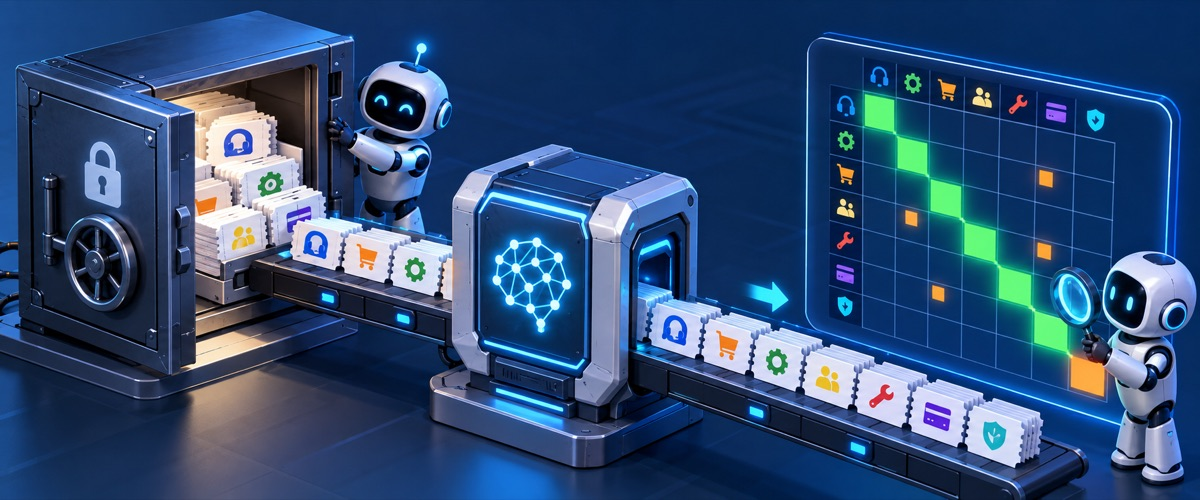

| Flow | Pass signal | Investigate if |
|---|---|---|
| Unlock 1,000 held-out tickets → predict once each → report metrics → inspect the confusion matrix | Accuracy and per-class recall stay high, with a bright diagonal and few scattered errors. | Urgent-queue recall drops, format fallbacks rise, or one off-diagonal confusion forms a pattern. |

These 1,000 tickets were split off *before* training and were never written to `TRAIN.json`,
so the model has never seen them. LLaMA Board's own **Val size** slice came out of the
training half — that is a different, smaller set used for early-stopping signal during the
run. The numbers below are therefore a genuine held-out estimate, not a re-read of anything
the optimiser touched.

The loop calls `classify()` on every row of `df_val` and collects predictions into `y_pred`.
Together with `y_true` (set when the base model was loaded, from the same dataframe) these
two lists feed every metric that follows.

Confidence is skipped here (`compute_confidence=False`) to keep the loop fast — this is
1,000 sequential forward passes and takes several minutes on a T4. Batching the prompts
would speed it up substantially; it is written one-at-a-time for clarity.

In [9]:
# --- 5.3  Evaluate fine-tuned model on val split ----------------------------
from tqdm.auto import tqdm

y_pred = []
for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Fine-tuned inference"):
    pred, _ = classify(row["text"], compute_confidence=False)
    y_pred.append(pred)

print(f"Evaluated {len(y_pred):,} samples.")


Fine-tuned inference:   0%|          | 0/1000 [00:00<?, ?it/s]

Evaluated 1,000 samples.


In [10]:
# --- 5.4  Classification report ---------------------------------------------
from sklearn.metrics import classification_report

# labels= pins the row order to LABEL_TOKENS so target_names lines up with the rows.
print(classification_report(y_true, y_pred, labels=LABEL_TOKENS,
                            target_names=LABEL_TOKENS, digits=3, zero_division=0))

# Show a few val examples with predictions
print()
for i in [0, 10, 20, 30]:
    row  = df_val.iloc[i]
    pred, conf = classify(row["text"])
    print(f"=== Ticket {i}")
    print(f"TRUE label: {row['label']}")
    print(f"PRED label: {pred}  (conf {conf:.1%})")
    print()

                   precision    recall  f1-score   support

  Support general      0.986     0.972     0.979       143
      Fileservice      1.000     0.986     0.993       143
             O365      1.000     0.993     0.996       142
              EOL      0.986     0.979     0.982       143
         Software      0.986     0.986     0.986       143
 Active Directory      0.953     0.993     0.973       143
Computer-Services      0.958     0.958     0.958       143

         accuracy                          0.981      1000
        macro avg      0.981     0.981     0.981      1000
     weighted avg      0.981     0.981     0.981      1000


=== Ticket 0
TRUE label: Active Directory
PRED label: Active Directory  (conf 100.0%)

=== Ticket 10
TRUE label: Computer-Services
PRED label: Computer-Services  (conf 100.0%)

=== Ticket 20
TRUE label: O365
PRED label: O365  (conf 100.0%)

=== Ticket 30
TRUE label: Support general
PRED label: Support general  (conf 100.0%)



### Reading the classification report

> ⚠️ **Same mislabeling as the baseline report.** The printed output above predates the
> `labels=LABEL_TOKENS` fix, so its per-class rows are in alphabetical order under the wrong
> names. The **accuracy line (0.981) is correct**, and the confusion matrix in the next cell
> was always correct. Re-run the cell to regenerate. Corrected table below.

**Fine-tuned — 1,000 held-out tickets, accuracy 98.1 % (19 errors)**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Active Directory | 0.986 | 0.972 | 0.979 | 143 |
| Computer-Services | 1.000 | 0.986 | 0.993 | 143 |
| EOL | 1.000 | 0.993 | 0.996 | 142 |
| Fileservice | 0.986 | 0.979 | 0.982 | 143 |
| O365 | 0.986 | 0.986 | 0.986 | 143 |
| Software | 0.953 | 0.993 | 0.973 | 143 |
| Support general | 0.958 | 0.958 | 0.958 | 143 |
| **accuracy** | | | **0.981** | **1000** |

### What the four columns mean

| Metric | What it measures |
|--------|-----------------|
| **Precision** | Of all tickets the model routed to this class, what fraction actually belonged there — the false-alarm rate for the team receiving them |
| **Recall** | Of all tickets that truly belong to this class, what fraction the model caught — the miss rate |
| **F1** | Harmonic mean of precision and recall — one balanced score per class |
| **Support** | Number of held-out tickets in this class (143, or 142 for EOL — the split does not divide evenly) |

### Routing cost asymmetry

Overall accuracy treats every mistake equally. A real helpdesk does not.

A misrouted `Active Directory` ticket means a new employee cannot log in on their first day —
high urgency, immediately visible to the business. A misrouted `Fileservice` ticket delays
access to shared files — serious, less acute. A misrouted `Support general` ticket wastes a
specialist's afternoon, but blocks no critical system.

**The metric that matters for a router is per-class recall on the high-urgency queues.**
A model at 90 % overall accuracy with 60 % `Active Directory` recall is sending 40 % of
account-provisioning requests to the wrong team. A model at 83 % overall with 95 %
`Active Directory` recall is safer in production, even though the headline looks worse.

In this run `Active Directory` recall is **97.2 %** — 4 missed out of 143. The weakest class
is `Support general` at 95.8 % recall, which is the right class to be weakest on: it is the
catch-all, and its misses mostly land in `Software` (see the matrix below).

The lowest precision is `Software` at 0.953 — it *receives* 7 tickets that belong elsewhere.
That means the Software queue carries a small amount of other teams' work, which is a mild
and self-correcting failure compared to dropping urgent tickets.

### Confusion matrix

The confusion matrix shows **where** the model makes mistakes, not just how many. Each row is
a true class; each column is what the model predicted. The diagonal is correct; everything
off-diagonal is an error.

The colour is row-normalised (each row sums to 1.0) so a dark diagonal cell means high
recall, while the printed numbers are raw counts so you can judge whether a pattern is real:
one confused ticket out of 143 is noise, five is a pattern.

This cell also prints `Active Directory` and `Fileservice` recall explicitly and warns if
AD recall drops below 0.85 — the two queues where a miss costs the most.

**Note:** unlike the two `classification_report` calls, this cell always passed
`labels=LABEL_TOKENS` to `confusion_matrix()`, so its axes were correct all along. It is the
ground truth for the corrected per-class tables in this notebook.

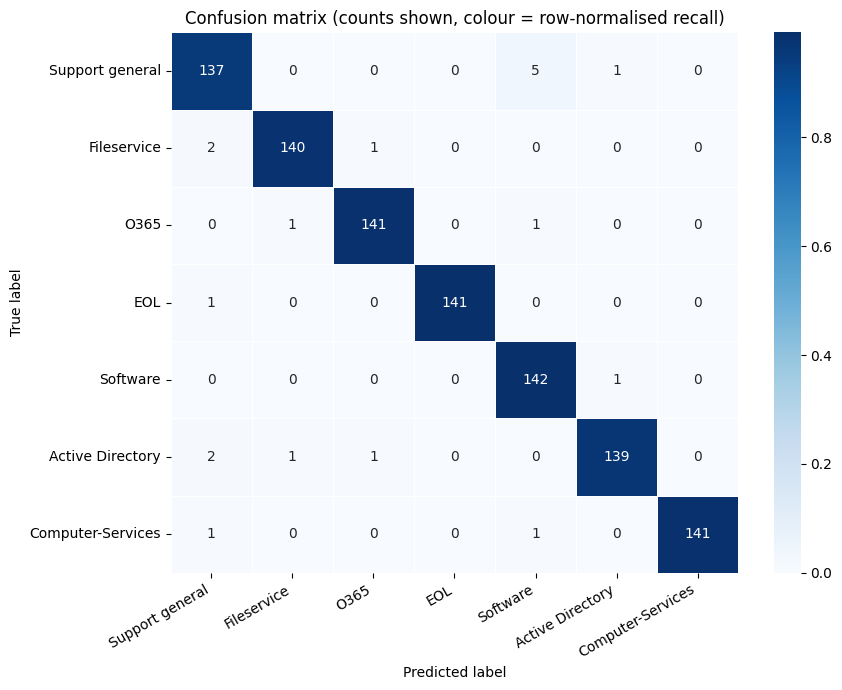


Active Directory recall : 97.2%
Fileservice recall      : 97.9%


In [11]:
# --- 5.5  Confusion matrix --------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(y_true, y_pred, labels=LABEL_TOKENS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_norm, annot=cm, fmt="d", cmap="Blues",
    xticklabels=LABEL_TOKENS, yticklabels=LABEL_TOKENS,
    linewidths=0.5, ax=ax,
)
ax.set_title("Confusion matrix (counts shown, colour = row-normalised recall)")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=120)
plt.show()

ad_recall   = cm_norm[LABEL_TOKENS.index("Active Directory"),   LABEL_TOKENS.index("Active Directory")]
file_recall = cm_norm[LABEL_TOKENS.index("Fileservice"),        LABEL_TOKENS.index("Fileservice")]
print(f"\nActive Directory recall : {ad_recall:.1%}")
print(f"Fileservice recall      : {file_recall:.1%}")
if ad_recall < 0.85:
    print("Warning: Active Directory recall below 0.85 — consider training longer.")

### Reading the confusion matrix

The reference run printed `Active Directory recall : 97.2%` and `Fileservice recall : 97.9%`,
and the matrix itself contains all 19 errors:

| True class | Correct | Where the misses went |
|---|---|---|
| Support general | 137 / 143 | **5 → Software**, 1 → Active Directory |
| Fileservice | 140 / 143 | 2 → Support general, 1 → O365 |
| O365 | 141 / 143 | 1 → Fileservice, 1 → Software |
| EOL | 141 / 142 | 1 → Support general |
| Software | 142 / 143 | 1 → Active Directory |
| Active Directory | 139 / 143 | 2 → Support general, 1 → Fileservice, 1 → O365 |
| Computer-Services | 141 / 143 | 1 → Support general, 1 → Software |

**The only systematic pattern is `Support general → Software` (5 tickets).** Everything else
is one or two tickets — statistically indistinguishable from label noise at this sample size.

That single pattern is worth understanding rather than fixing blindly. `Support general` is
the catch-all, and a general ticket that mentions an application ("this app is behaving
strangely, can someone look?") is genuinely ambiguous — a human triager might well send it to
Software too. Before spending another training run on it, pull those five tickets and read
them; if the gold labels are debatable, the ceiling here is the label quality, not the model.

**No off-diagonal cell exceeds 5.** There is no confused *pair* — no two classes the model
systematically cannot tell apart — which is the failure mode that would actually indicate a
taxonomy or data problem.

---
## 8. Baseline vs Fine-tuned Comparison

### Robot checkpoint — Quantify what fine-tuning bought

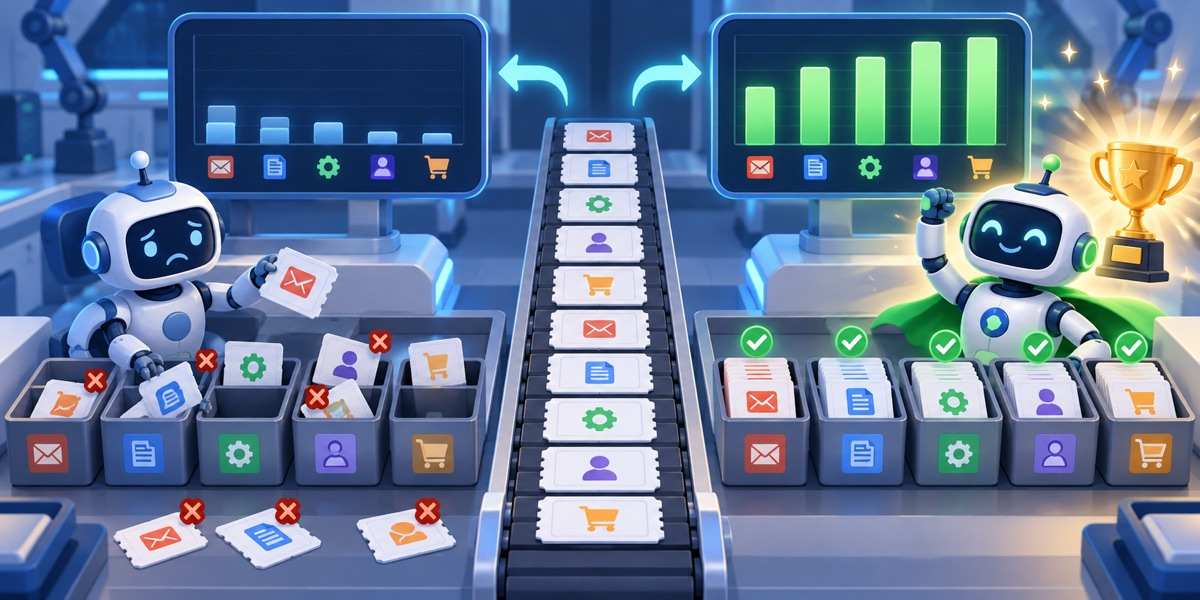

| Flow | Pass signal | Investigate if |
|---|---|---|
| Same held-out tickets → base-model score beside fine-tuned score → inspect per-class and overall gain | The fine-tuned model improves every important route; the reference gain is 20.9% → 98.1%. | A class regresses, the test sets differ, or the comparison hides a decoding-method advantage. |

### What "baseline" means here

The baseline is the same weights fine-tuning started from, scored on the same held-out
tickets, with **zero task-specific training**. It represents what the model knows purely from
pre-training — general language understanding, some IT domain knowledge absorbed from
internet text — with no exposure to your labelled examples.

Because it was measured in cell 5.2 *before* the adapter was attached, it is a true control:
same tokenizer, same tickets, same machine, same code path up to that point.

### Why a letter-choice prompt for the baseline?

A naive baseline would ask the model to generate the label string directly. But an untrained
base model has no reason to prefer exactly `"Active Directory"` over `"active directory"`,
`"AD"`, or a full sentence — string matching would fail unpredictably and we would be
measuring formatting, not routing.

So the baseline gets a **constrained multiple-choice format**: seven options labelled `A`–`G`,
scored by comparing the logits of those seven single tokens at the first generated position.
Single letters are unambiguous single tokens, the comparison is clean, and the prediction is
always a valid class. This gives the base model its best possible shot.

### What the delta tells you — and what it doesn't

The gap between baseline and fine-tuned accuracy is the measurable value of your labelled
data plus the training run. A large gain on classes that were near-zero in the baseline
confirms the model learned task-specific routing signal rather than surfacing something it
already knew.

What the delta does *not* isolate: the two models are scored through **different decoding
paths** (letter logits vs. generate-and-match), so some of the gap is the fine-tuned model's
fluency with the required output format. That is still real value — a router that cannot emit
a parseable label is useless — but it is format learning, not routing skill. Read the delta as
"what fine-tuning bought me end to end", not as a pure measurement of learned classification.

### The chart

`per_class_f1()` extracts the per-class F1 from a `classification_report` dict for each model,
then plots them side by side: light blue = base, dark blue = fine-tuned, with the overall
accuracy pair highlighted in orange on the right of the dashed separator. Saved to
`/content/baseline_vs_finetuned.png`.

### Reading the comparison chart

Each class has two bars: light blue for the base model, dark blue for the fine-tuned model.
The pair to the right of the dashed line is overall accuracy.

> ⚠️ **The saved chart below carries the same class-name mislabeling** as the two reports —
> `per_class_f1()` called `classification_report` without `labels=`, so the per-class bars
> were drawn under alphabetically-ordered names. The **overall accuracy pair (0.21 vs 0.98)
> is correct**, since accuracy does not depend on class ordering. The code is now fixed;
> re-run the cell to regenerate the chart with correct per-class names.

What to look for once regenerated:

- **Classes where the base model scores ~zero** (`Computer-Services` 0.00, `Active Directory`
  and `O365` 0.01) — the base model contributes nothing there; fine-tuning taught the model
  everything it knows about those routes.
- **Classes where the base model already had signal** (`EOL` F1 0.42, `Support general` 0.26) —
  `EOL` because "decommission / retire this server" is unambiguous in plain English,
  `Support general` only because it was option `A)` and collected the model's default answer.
- **Classes where the fine-tuned model regressed** — none here. A regression would point to a
  class that was under-represented or ambiguously labelled in training.
- **The overall delta** — printed under the chart: **20.9 % → 98.1 %, +77.2 points**.
  For a clean, balanced, single-intent dataset like this one, a jump into the high nineties is
  normal. Do not expect it to transfer to messy real-world tickets with multiple intents,
  inconsistent human labels, and long tails — see *Limitations* in `README.md`.

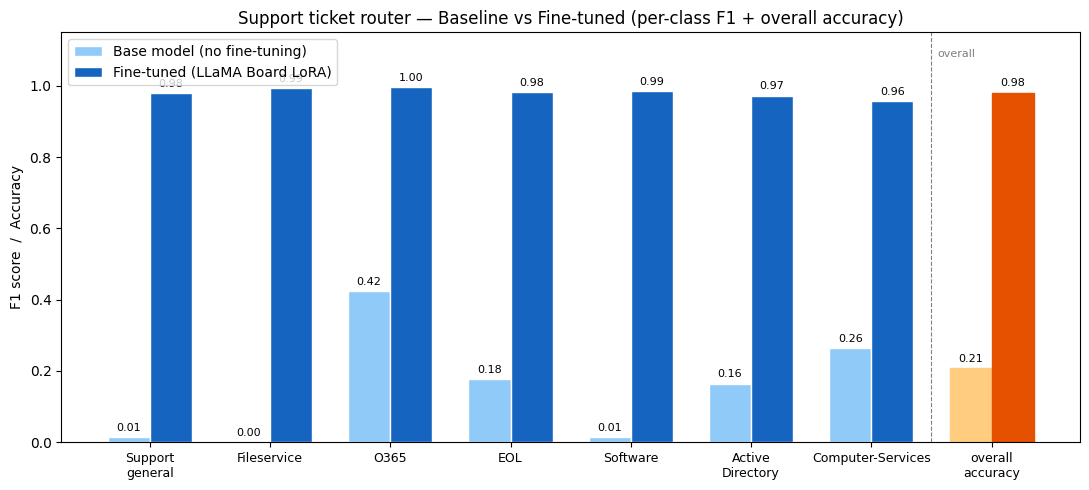


Base accuracy  : 20.9%
Fine-tuned acc : 98.1%
Delta          : +77.2%


In [12]:
# --- 5.7b  Comparison chart: baseline vs fine-tuned ------------------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, accuracy_score


def per_class_f1(y_t, y_p, labels):
    # labels= keeps the dict keyed by our class order; without it the per-class F1
    # scores get attached to the wrong class names (same trap as cell 5.4).
    report = classification_report(y_t, y_p, labels=labels, target_names=labels,
                                   output_dict=True, zero_division=0)
    return {lbl: report[lbl]["f1-score"] for lbl in labels}


ft_f1    = per_class_f1(y_true, y_pred,      LABEL_TOKENS)
base_f1  = per_class_f1(y_true, y_pred_base, LABEL_TOKENS)
ft_acc   = accuracy_score(y_true, y_pred)
base_acc = accuracy_score(y_true, y_pred_base)

labels_plot = LABEL_TOKENS + ["overall accuracy"]
ft_vals     = [ft_f1[l]   for l in LABEL_TOKENS] + [ft_acc]
base_vals   = [base_f1[l] for l in LABEL_TOKENS] + [base_acc]

x     = np.arange(len(labels_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_base = ax.bar(x - width/2, base_vals, width, label="Base model (no fine-tuning)", color="#90CAF9", edgecolor="white")
bars_ft   = ax.bar(x + width/2, ft_vals,   width, label="Fine-tuned (LLaMA Board LoRA)", color="#1565C0", edgecolor="white")

ax.bar_label(bars_base, fmt="{:.2f}", padding=3, fontsize=8)
ax.bar_label(bars_ft,   fmt="{:.2f}", padding=3, fontsize=8)
bars_base[-1].set_color("#FFCC80")
bars_ft[-1].set_color("#E65100")

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels([l.replace(" ", "\n") for l in labels_plot], fontsize=9)
ax.set_ylabel("F1 score  /  Accuracy")
ax.set_title("Support ticket router — Baseline vs Fine-tuned (per-class F1 + overall accuracy)")
ax.legend()
ax.axvline(len(LABEL_TOKENS) - 0.5, color="grey", linestyle="--", linewidth=0.8)
ax.text(len(LABEL_TOKENS) - 0.5 + 0.05, 1.08, "overall", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("/content/baseline_vs_finetuned.png", dpi=120)
plt.show()

print(f"\nBase accuracy  : {base_acc:.1%}")
print(f"Fine-tuned acc : {ft_acc:.1%}")
print(f"Delta          : +{(ft_acc - base_acc):.1%}")

---
## Results Summary

| | Base model | Fine-tuned | Δ |
|---|---|---|---|
| **Overall accuracy** (1,000 held-out tickets) | 20.9 % | **98.1 %** | **+77.2 pts** |
| Macro F1 | 0.151 | 0.981 | +0.830 |
| Active Directory recall | 0.7 % | **97.2 %** | +96.5 pts |
| Errors | 791 | **19** | −772 |
| Final training loss | — | 0.0028 after 750 steps | — |

Artefacts written to `/content`: `training_curve.png`, `confusion_matrix.png`,
`baseline_vs_finetuned.png`. The merged, standalone model is in `/content/qwen3_merged`
and loads with a plain `AutoModelForCausalLM.from_pretrained()`.

**Download anything you want to keep before the Colab runtime recycles** — `/content` is
ephemeral:

```python
from google.colab import files
files.download("/content/confusion_matrix.png")
# the merged model is several GB — zip it or push it to the Hugging Face Hub instead
```

## Where to go next

- **Harden the comparison.** Score *both* models by teacher-forced log-likelihood over the
  seven label strings, so neither one wins on output formatting. This is the single biggest
  improvement available to the evaluation.
- **Instrument the fallback.** Count how often `classify()` fails to prefix-match and falls
  back to `Support general`; a nonzero count means some of the reported accuracy is
  format failure in disguise.
- **Calibrate a review threshold.** Plot accuracy against the confidence score and pick the
  cut-off where routing low-confidence tickets to human triage buys the most safety for the
  least human effort. The smoke-test miss above was flagged at 61 % confidence.
- **Test on real tickets.** This dataset is balanced, single-intent and redacted. Production
  traffic is none of those. Expect a drop, and re-measure on a sample of live tickets before
  trusting any number here.
- **Batch inference.** The evaluation loop is one ticket per forward pass. Batching gives a
  large speed-up for the same result.